# Score-Control Runs: Qwen + Llama

This notebook auto-loads the **latest local control-suite runs** for both model families and compares directional `s(x)` steering against matched controls.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set_theme(style='whitegrid', context='talk')
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 220)

DATA_DIR = Path(r"C:/Users/mikol/OneDrive/Pulpit/Praca Magisterska/data")
RUN_SPECS = [
    ('Qwen 0.5B', 'Qwen-Qwen2.5-0.5B-Instruct'),
    ('Qwen 3B', 'Qwen-Qwen2.5-3B-Instruct'),
    ('Qwen 7B', 'Qwen-Qwen2.5-7B-Instruct'),
    ('Llama 1B', 'meta-llama-Llama-3.2-1B-Instruct'),
    ('Llama 3B', 'meta-llama-Llama-3.2-3B-Instruct'),
]
MODEL_ORDER = [label for label, _ in RUN_SPECS]

def latest_run_dir(model_fragment: str) -> Path:
    candidates = sorted(DATA_DIR.glob(f"*_{model_fragment}_csqa_logit_feature_score_control_pipeline"))
    if not candidates:
        raise FileNotFoundError(f"No local control-suite run found for: {model_fragment}")
    return candidates[-1]

def model_family(label: str) -> str:
    return label.split()[0]

def model_size(label: str) -> str:
    return label.split()[1]

def apply_model_order(frame: pd.DataFrame, column: str = 'model') -> pd.DataFrame:
    frame = frame.copy()
    frame[column] = pd.Categorical(frame[column], categories=MODEL_ORDER, ordered=True)
    return frame

RUNS = [(label, latest_run_dir(fragment)) for label, fragment in RUN_SPECS]

FEATURE_LABELS = {
    'answer_choice_top1_top2_logit_gap': 'gap',
    'answer_choice_varentropy': 'varentropy',
}
INTERVENTION_COLORS = {
    'ascent': '#1f77b4',
    'descent': '#d62728',
    'random_same_norm': '#9467bd',
}
OUTCOME_COLORS = {
    'rescued': '#2ca02c',
    'harmed': '#d62728',
    'wrong_to_wrong': '#ff7f0e',
    'unchanged': '#7f7f7f',
}


In [2]:
def load_control_run(label: str, run_dir: Path) -> dict:
    df = pd.read_parquet(run_dir / 'train_score_control_policy_outputs_raw.parquet')
    clean = pd.read_parquet(run_dir / 'train_clean_final_outputs.parquet')
    selected = pd.read_parquet(run_dir / 'selected_layers_by_feature.parquet')
    sep = pd.read_parquet(run_dir / 'feature_layer_separation_summary.parquet')
    grid = pd.read_parquet(run_dir / 'fit_distribution_grid.parquet')

    clean_cols = [f'clean_logit_{c}' for c in 'ABCDE']
    steered_cols = [f'steered_logit_{c}' for c in 'ABCDE']
    clean['clean_pred_idx'] = clean[clean_cols].to_numpy().argmax(axis=1)
    clean['clean_is_correct'] = clean['clean_pred_idx'] == clean['true_choice_idx']

    df = df.merge(clean[['example_id', 'true_choice_idx', 'clean_is_correct']], on='example_id', how='left')
    df['steered_pred_idx'] = df[steered_cols].to_numpy().argmax(axis=1)
    df['steered_is_correct'] = df['steered_pred_idx'] == df['true_choice_idx']
    df['clean_top_is_correct'] = df['clean_is_correct']
    df['rescued'] = (~df['clean_is_correct']) & (df['steered_is_correct'])
    df['harmed'] = (df['clean_is_correct']) & (~df['steered_is_correct'])
    df['wrong_to_wrong'] = (~df['clean_is_correct']) & (~df['steered_is_correct'])
    df['unchanged'] = (df['clean_is_correct']) & (df['steered_is_correct'])
    df['outcome_label'] = np.select(
        [df['rescued'], df['harmed'], df['wrong_to_wrong']],
        ['rescued', 'harmed', 'wrong_to_wrong'],
        default='unchanged',
    )
    df['score_gain'] = df['steered_score_value_local'] - df['current_score_value']

    correct_clean = []
    correct_steered = []
    for _, row in df.iterrows():
        idx = int(row['true_choice_idx'])
        letter = 'ABCDE'[idx]
        correct_clean.append(row[f'clean_logit_{letter}'])
        correct_steered.append(row[f'steered_logit_{letter}'])
    df['correct_choice_logit_clean'] = correct_clean
    df['correct_choice_logit_steered'] = correct_steered
    df['correct_choice_logit_change'] = df['correct_choice_logit_steered'] - df['correct_choice_logit_clean']
    df['feature'] = df['feature_name'].map(FEATURE_LABELS)
    df['model'] = label
    df['family'] = model_family(label)
    df['size'] = model_size(label)

    max_layer = int(sep['layer_number'].max()) if len(sep) else int(df['layer_number'].max())
    for frame in (df, selected, sep, grid):
        frame['layer_pct'] = 100.0 * frame['layer_number'] / max_layer
    return {
        'label': label,
        'family': model_family(label),
        'size': model_size(label),
        'dir': run_dir,
        'df': df,
        'selected': selected,
        'separation': sep,
        'grid': grid,
        'max_layer': max_layer,
    }

runs = [load_control_run(label, path) for label, path in RUNS if path.exists()]
run_index = pd.DataFrame({
    'model': [r['label'] for r in runs],
    'family': [r['family'] for r in runs],
    'size': [r['size'] for r in runs],
    'max_layer': [r['max_layer'] for r in runs],
    'run_dir': [str(r['dir']) for r in runs],
})
run_index = apply_model_order(run_index).sort_values('model').reset_index(drop=True)
display(run_index)


,model,family,size,max_layer,run_dir
0,Qwen 0.5B,Qwen,0.5B,24,C:\Users\mikol\OneDrive\Pulpit\Praca Magisters...
1,Qwen 3B,Qwen,3B,36,C:\Users\mikol\OneDrive\Pulpit\Praca Magisters...
2,Qwen 7B,Qwen,7B,28,C:\Users\mikol\OneDrive\Pulpit\Praca Magisters...
3,Llama 1B,Llama,1B,16,C:\Users\mikol\OneDrive\Pulpit\Praca Magisters...
4,Llama 3B,Llama,3B,28,C:\Users\mikol\OneDrive\Pulpit\Praca Magisters...


In [3]:
overview_rows = []
for run in runs:
    df = run['df']
    overview_rows.append({
        'model': run['label'],
        'family': run['family'],
        'size': run['size'],
        'rows': len(df),
        'examples': df['example_id'].nunique(),
        'intervention_types': df['intervention_type'].nunique(),
        'mean_delta': df['delta_over_token_hidden_l2'].mean(),
        'median_delta': df['delta_over_token_hidden_l2'].median(),
        'rescued_total': int(df['rescued'].sum()),
        'harmed_total': int(df['harmed'].sum()),
        'net_total': int(df['rescued'].sum() - df['harmed'].sum()),
        'net_rate': (df['rescued'].sum() - df['harmed'].sum()) / len(df),
    })
overview = pd.DataFrame(overview_rows)
overview = apply_model_order(overview).sort_values('model').reset_index(drop=True)
display(overview)


,model,family,size,rows,examples,intervention_types,mean_delta,median_delta,rescued_total,harmed_total,net_total,net_rate
0,Qwen 0.5B,Qwen,0.5B,22581,650,3,0.004778,0.005,471,623,-152,-0.006731
1,Qwen 3B,Qwen,3B,22740,650,3,0.004811,0.005,112,160,-48,-0.002111
2,Qwen 7B,Qwen,7B,22587,650,3,0.004872,0.005,268,248,20,0.000885
3,Llama 1B,Llama,1B,22593,650,3,0.004635,0.005,394,638,-244,-0.010800
4,Llama 3B,Llama,3B,22878,650,3,0.004935,0.005,161,262,-101,-0.004415


## Selected Layers And KS Statistics

In [ ]:
selected_all = pd.concat([
    r['selected'].assign(model=r['label'], family=r['family'], size=r['size'])
    for r in runs
], ignore_index=True)
selected_all['feature'] = selected_all['feature_name'].map(FEATURE_LABELS)
selected_all = apply_model_order(selected_all).sort_values(['model', 'feature', 'layer_number']).reset_index(drop=True)
display(selected_all[['model', 'family', 'size', 'feature', 'layer_number', 'layer_pct']])

,model,family,size,feature,layer_number,layer_pct
0,Qwen 0.5B,Qwen,0.5B,gap,17,70.833333
1,Qwen 0.5B,Qwen,0.5B,gap,19,79.166667
2,Qwen 0.5B,Qwen,0.5B,gap,21,87.500000
3,Qwen 0.5B,Qwen,0.5B,gap,22,91.666667
4,Qwen 0.5B,Qwen,0.5B,gap,23,95.833333
5,Qwen 0.5B,Qwen,0.5B,gap,24,100.000000
6,Qwen 0.5B,Qwen,0.5B,varentropy,9,37.500000
7,Qwen 0.5B,Qwen,0.5B,varentropy,17,70.833333
8,Qwen 0.5B,Qwen,0.5B,varentropy,20,83.333333
9,Qwen 0.5B,Qwen,0.5B,varentropy,21,87.500000


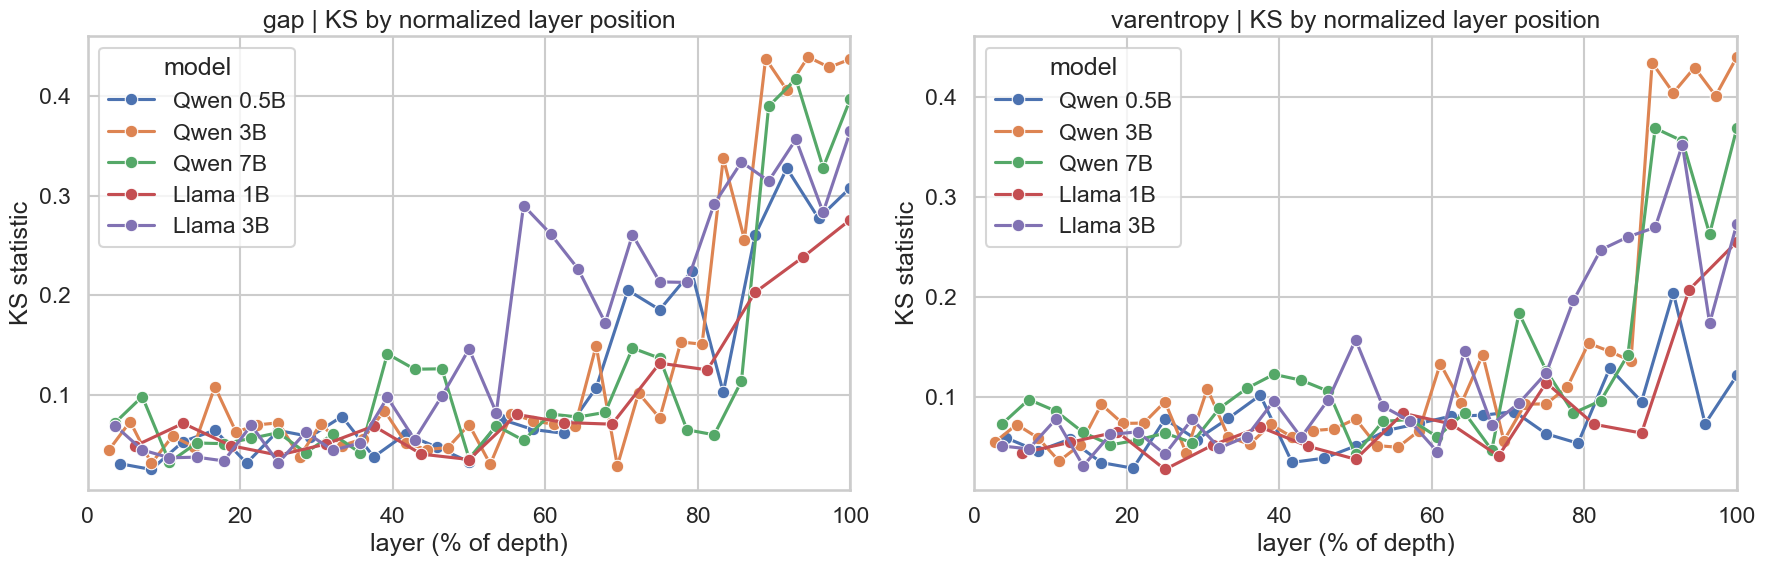

In [5]:
sep_all = pd.concat([
    r['separation'].assign(model=r['label'], family=r['family'], size=r['size'])
    for r in runs
], ignore_index=True)
sep_all['feature'] = sep_all['feature_name'].map(FEATURE_LABELS)
sep_all = apply_model_order(sep_all).sort_values(['model', 'layer_pct']).reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=False)
for ax, feature in zip(axes, ['gap', 'varentropy']):
    tmp = sep_all[sep_all['feature'] == feature].copy().sort_values(['model', 'layer_pct'])
    sns.lineplot(data=tmp, x='layer_pct', y='ks_statistic', hue='model', marker='o', ax=ax)
    ax.set_title(f'{feature} | KS by normalized layer position')
    ax.set_xlabel('layer (% of depth)')
    ax.set_ylabel('KS statistic')
    ax.set_xlim(0, 100)
    ax.legend(title='model')
plt.tight_layout()
plt.show()


## `s(x)` Curves For Selected Feature/Layer Pairs

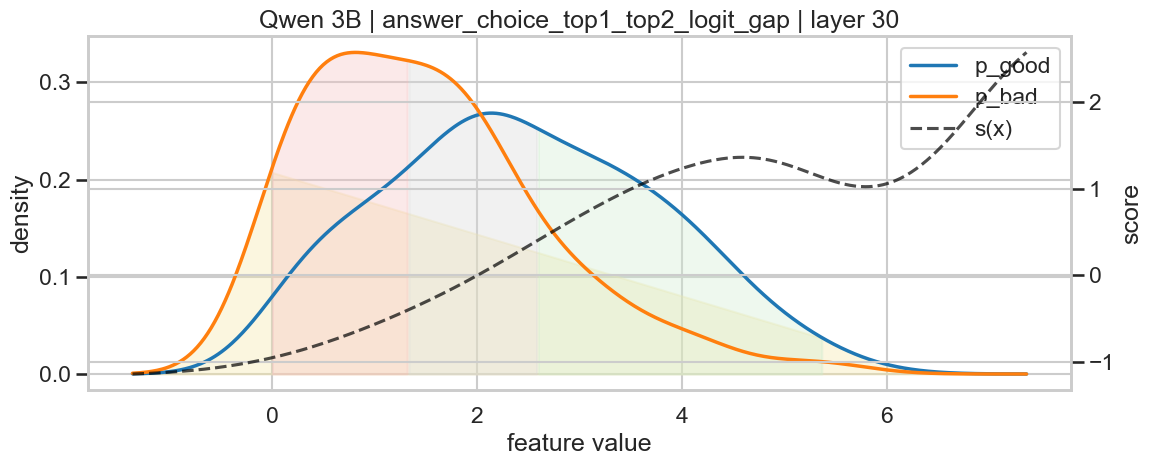

In [36]:
def plot_score_curve(run, feature_name, layer_number):
    grid = run['grid']
    grid = grid[(grid['feature_name'] == feature_name) & (grid['layer_number'] == layer_number)].copy().sort_values('grid_x')
    if grid.empty:
        print('No grid rows for selection')
        return
    fig, ax = plt.subplots(figsize=(12, 5))
    for region, color in [('unsupported', '#f4e6a6'), ('bad', '#f6c1c1'), ('neutral', '#d9d9d9'), ('good', '#cfeccf')]:
        reg = grid[grid['region_label'] == region]
        if not reg.empty:
            ax.fill_between(reg['grid_x'], 0, np.maximum(reg['p_good'], reg['p_bad']), color=color, alpha=0.35)
    ax.plot(grid['grid_x'], grid['p_good'], label='p_good', color='#1f77b4', lw=2.5)
    ax.plot(grid['grid_x'], grid['p_bad'], label='p_bad', color='#ff7f0e', lw=2.5)
    ax.set_xlabel('feature value')
    ax.set_ylabel('density')
    ax.set_title(f"{run['label']} | {feature_name} | layer {layer_number}")
    ax2 = ax.twinx()
    ax2.plot(grid['grid_x'], grid['log_density_ratio'], '--', color='black', alpha=0.7, label='s(x)')
    ax2.set_ylabel('score')
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
    plt.tight_layout()
    plt.show()

# Manual cell
MODEL = 'Qwen 3B'
FEATURE_NAME = 'answer_choice_top1_top2_logit_gap'
LAYER_NUMBER = 30
run = next(r for r in runs if r['label'] == MODEL)
plot_score_curve(run, FEATURE_NAME, LAYER_NUMBER)


## Control Comparison: Overall Outcomes

In [7]:
all_df = pd.concat([r['df'] for r in runs], ignore_index=True)
all_df = apply_model_order(all_df)
summary = all_df.groupby(['model', 'intervention_type'], observed=False).agg(
    rows=('example_id', 'size'),
    rescued=('rescued', 'sum'),
    harmed=('harmed', 'sum'),
    mean_score_gain=('score_gain', 'mean'),
    mean_correct_logit_change=('correct_choice_logit_change', 'mean'),
    mean_delta=('delta_over_token_hidden_l2', 'mean'),
).reset_index()
summary['rescue_rate'] = summary['rescued'] / summary['rows']
summary['harm_rate'] = summary['harmed'] / summary['rows']
summary['net_rate'] = (summary['rescued'] - summary['harmed']) / summary['rows']
summary = apply_model_order(summary).sort_values(['model', 'intervention_type']).reset_index(drop=True)
display(summary)


,model,intervention_type,rows,rescued,harmed,mean_score_gain,mean_correct_logit_change,mean_delta,rescue_rate,harm_rate,net_rate
0,Qwen 0.5B,ascent,7527,86,73,0.140791,0.048990,0.004778,0.011426,0.009698,0.001727
1,Qwen 0.5B,descent,7527,299,486,-0.110121,-0.011924,0.004778,0.039724,0.064568,-0.024844
2,Qwen 0.5B,random_same_norm,7527,86,64,0.000005,0.018674,0.004778,0.011426,0.008503,0.002923
3,Qwen 3B,ascent,7580,35,44,0.186214,0.044706,0.004811,0.004617,0.005805,-0.001187
4,Qwen 3B,descent,7580,43,63,-0.187518,-0.106844,0.004811,0.005673,0.008311,-0.002639
5,Qwen 3B,random_same_norm,7580,34,53,0.000109,-0.027177,0.004811,0.004485,0.006992,-0.002507
6,Qwen 7B,ascent,7529,88,88,0.226270,0.073217,0.004872,0.011688,0.011688,0.000000
7,Qwen 7B,descent,7529,85,94,-0.187018,-0.113511,0.004872,0.011290,0.012485,-0.001195
8,Qwen 7B,random_same_norm,7529,95,66,-0.000310,-0.012435,0.004872,0.012618,0.008766,0.003852
9,Llama 1B,ascent,7531,56,86,0.150866,0.040615,0.004635,0.007436,0.011419,-0.003984


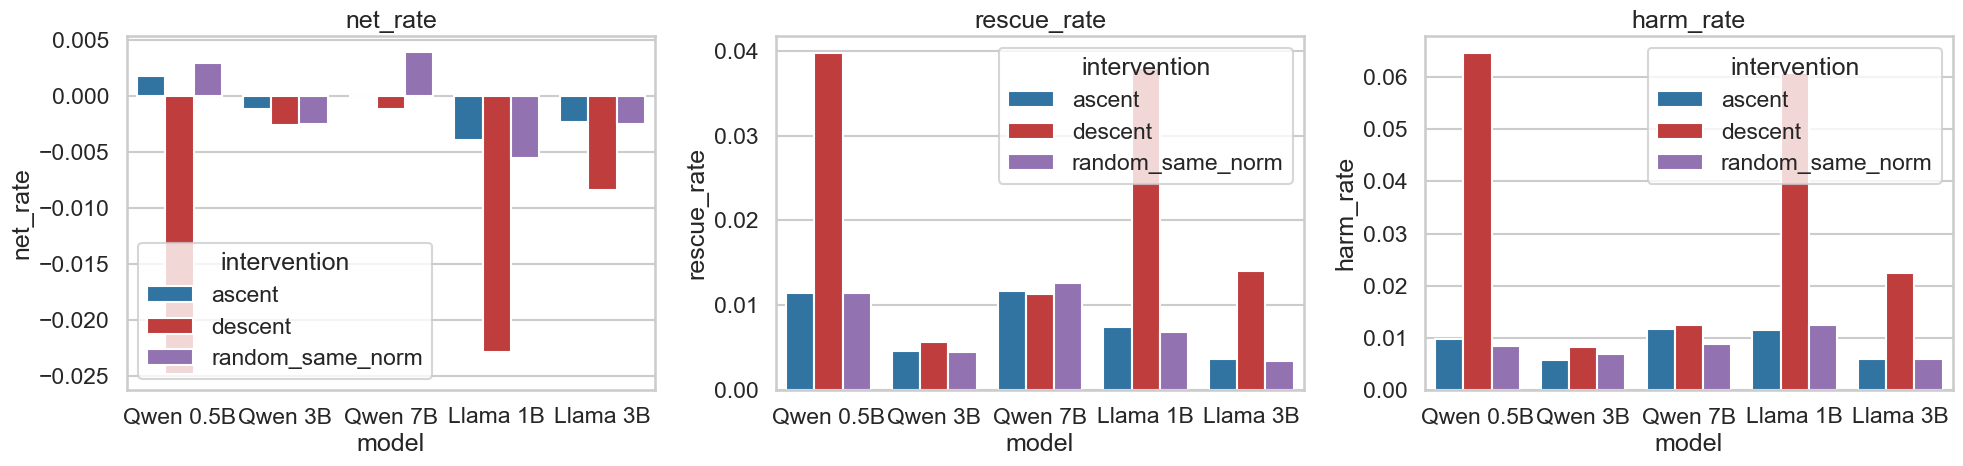

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5), sharey=False)
for ax, metric in zip(axes, ['net_rate', 'rescue_rate', 'harm_rate']):
    sns.barplot(data=summary, x='model', y=metric, hue='intervention_type', palette=INTERVENTION_COLORS, ax=ax)
    ax.set_title(metric)
    ax.legend(title='intervention')
plt.tight_layout()
plt.show()


## Main Question: Does Direction Beat The Controls?

This section compares the three matched branches directly:

- `ascent`: move along the accepted `s(x)` direction
- `descent`: move by the same norm in the opposite direction
- `random_same_norm`: random perturbation with the same norm

Because all three branches reuse the same accepted perturbation scale, these comparisons isolate **direction**, not just perturbation size.


In [9]:
# 1. Same-size sanity check: are all three branches really matched in norm?
matched_norms = all_df.groupby(['model', 'intervention_type'], observed=False).agg(
    rows=('example_id', 'size'),
    mean_delta=('delta_over_token_hidden_l2', 'mean'),
    median_delta=('delta_over_token_hidden_l2', 'median'),
    mean_score_gain=('score_gain', 'mean'),
    median_score_gain=('score_gain', 'median'),
).reset_index()
matched_norms = apply_model_order(matched_norms).sort_values(['model', 'intervention_type']).reset_index(drop=True)
display(matched_norms)


,model,intervention_type,rows,mean_delta,median_delta,mean_score_gain,median_score_gain
0,Qwen 0.5B,ascent,7527,0.004778,0.005,0.140791,0.125135
1,Qwen 0.5B,descent,7527,0.004778,0.005,-0.110121,-0.094475
2,Qwen 0.5B,random_same_norm,7527,0.004778,0.005,0.000005,0.000000
3,Qwen 3B,ascent,7580,0.004811,0.005,0.186214,0.154113
4,Qwen 3B,descent,7580,0.004811,0.005,-0.187518,-0.168487
5,Qwen 3B,random_same_norm,7580,0.004811,0.005,0.000109,0.000000
6,Qwen 7B,ascent,7529,0.004872,0.005,0.226270,0.203363
7,Qwen 7B,descent,7529,0.004872,0.005,-0.187018,-0.177330
8,Qwen 7B,random_same_norm,7529,0.004872,0.005,-0.000310,0.000000
9,Llama 1B,ascent,7531,0.004635,0.005,0.150866,0.112173


In [10]:
# 2. Direct branch comparison: overall rescue/harm/net by intervention type
branch_summary = all_df.groupby(['model', 'intervention_type'], observed=False).agg(
    rows=('example_id', 'size'),
    rescued=('rescued', 'sum'),
    harmed=('harmed', 'sum'),
    rescue_rate=('rescued', 'mean'),
    harm_rate=('harmed', 'mean'),
    mean_correct_logit_change=('correct_choice_logit_change', 'mean'),
    mean_score_gain=('score_gain', 'mean'),
).reset_index()
branch_summary['net'] = branch_summary['rescued'] - branch_summary['harmed']
branch_summary['net_rate'] = branch_summary['rescue_rate'] - branch_summary['harm_rate']
branch_summary = apply_model_order(branch_summary).sort_values(['model', 'intervention_type']).reset_index(drop=True)
display(branch_summary)


,model,intervention_type,rows,rescued,harmed,rescue_rate,harm_rate,mean_correct_logit_change,mean_score_gain,net,net_rate
0,Qwen 0.5B,ascent,7527,86,73,0.011426,0.009698,0.048990,0.140791,13,0.001727
1,Qwen 0.5B,descent,7527,299,486,0.039724,0.064568,-0.011924,-0.110121,-187,-0.024844
2,Qwen 0.5B,random_same_norm,7527,86,64,0.011426,0.008503,0.018674,0.000005,22,0.002923
3,Qwen 3B,ascent,7580,35,44,0.004617,0.005805,0.044706,0.186214,-9,-0.001187
4,Qwen 3B,descent,7580,43,63,0.005673,0.008311,-0.106844,-0.187518,-20,-0.002639
5,Qwen 3B,random_same_norm,7580,34,53,0.004485,0.006992,-0.027177,0.000109,-19,-0.002507
6,Qwen 7B,ascent,7529,88,88,0.011688,0.011688,0.073217,0.226270,0,0.000000
7,Qwen 7B,descent,7529,85,94,0.011290,0.012485,-0.113511,-0.187018,-9,-0.001195
8,Qwen 7B,random_same_norm,7529,95,66,0.012618,0.008766,-0.012435,-0.000310,29,0.003852
9,Llama 1B,ascent,7531,56,86,0.007436,0.011419,0.040615,0.150866,-30,-0.003984


In [11]:
# 3. Condensed comparison table: ascent vs descent and ascent vs random
rows = []
for model, grp in branch_summary.groupby('model', observed=False):
    grp = grp.set_index('intervention_type')
    rows.append({
        'model': model,
        'ascent_net_rate': grp.loc['ascent', 'net_rate'],
        'descent_net_rate': grp.loc['descent', 'net_rate'],
        'random_net_rate': grp.loc['random_same_norm', 'net_rate'],
        'ascent_minus_descent': grp.loc['ascent', 'net_rate'] - grp.loc['descent', 'net_rate'],
        'ascent_minus_random': grp.loc['ascent', 'net_rate'] - grp.loc['random_same_norm', 'net_rate'],
        'ascent_score_gain': grp.loc['ascent', 'mean_score_gain'],
        'descent_score_gain': grp.loc['descent', 'mean_score_gain'],
        'random_score_gain': grp.loc['random_same_norm', 'mean_score_gain'],
    })
comparison = pd.DataFrame(rows)
comparison = apply_model_order(comparison).sort_values('model').reset_index(drop=True)
display(comparison)


,model,ascent_net_rate,descent_net_rate,random_net_rate,ascent_minus_descent,ascent_minus_random,ascent_score_gain,descent_score_gain,random_score_gain
0,Qwen 0.5B,0.001727,-0.024844,0.002923,0.026571,-0.001196,0.140791,-0.110121,0.000005
1,Qwen 3B,-0.001187,-0.002639,-0.002507,0.001451,0.001319,0.186214,-0.187518,0.000109
2,Qwen 7B,0.000000,-0.001195,0.003852,0.001195,-0.003852,0.226270,-0.187018,-0.000310
3,Llama 1B,-0.003984,-0.022839,-0.005577,0.018855,0.001593,0.150866,-0.094423,-0.000018
4,Llama 3B,-0.002360,-0.008392,-0.002491,0.006032,0.000131,0.166600,-0.148728,-0.000161


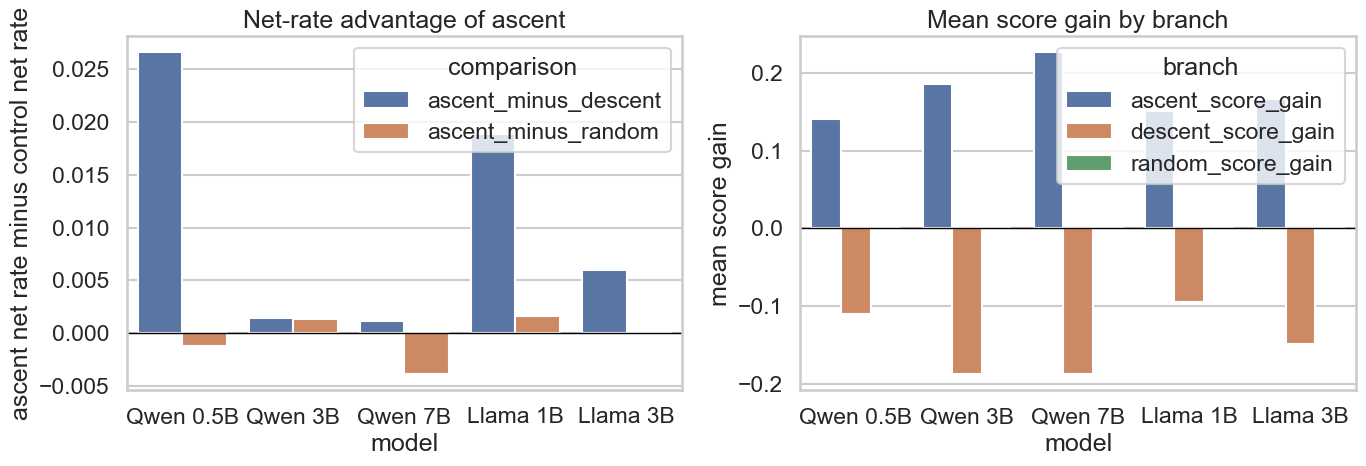

In [12]:
# 4. Visual: does ascent outperform descent and random?
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)
comp_long = comparison.melt(
    id_vars='model',
    value_vars=['ascent_minus_descent', 'ascent_minus_random'],
    var_name='comparison',
    value_name='net_rate_diff',
)
sns.barplot(data=comp_long, x='model', y='net_rate_diff', hue='comparison', ax=axes[0])
axes[0].axhline(0, color='black', lw=1)
axes[0].set_title('Net-rate advantage of ascent')
axes[0].set_ylabel('ascent net rate minus control net rate')
axes[0].legend(title='comparison')

score_long = comparison.melt(
    id_vars='model',
    value_vars=['ascent_score_gain', 'descent_score_gain', 'random_score_gain'],
    var_name='branch',
    value_name='mean_score_gain',
)
sns.barplot(data=score_long, x='model', y='mean_score_gain', hue='branch', ax=axes[1])
axes[1].axhline(0, color='black', lw=1)
axes[1].set_title('Mean score gain by branch')
axes[1].set_ylabel('mean score gain')
axes[1].legend(title='branch')
plt.tight_layout()
plt.show()


In [13]:
# 5. Matched per-example comparison: how often is ascent actually better?
def build_matched_comparison(run):
    df = run['df'].copy()
    df['net_outcome'] = df['rescued'].astype(int) - df['harmed'].astype(int)
    key = ['example_id', 'feature_name', 'layer_number']
    piv = df.pivot_table(index=key, columns='intervention_type', values=['net_outcome', 'steered_is_correct'], aggfunc='first')
    piv.columns = ['__'.join(col) for col in piv.columns]
    piv = piv.reset_index()
    return pd.Series({
        'ascent_better_than_descent_frac': (piv['net_outcome__ascent'] > piv['net_outcome__descent']).mean(),
        'ascent_worse_than_descent_frac': (piv['net_outcome__ascent'] < piv['net_outcome__descent']).mean(),
        'ascent_better_than_random_frac': (piv['net_outcome__ascent'] > piv['net_outcome__random_same_norm']).mean(),
        'ascent_worse_than_random_frac': (piv['net_outcome__ascent'] < piv['net_outcome__random_same_norm']).mean(),
        'ascent_more_correct_than_descent_frac': (piv['steered_is_correct__ascent'] > piv['steered_is_correct__descent']).mean(),
        'ascent_less_correct_than_descent_frac': (piv['steered_is_correct__ascent'] < piv['steered_is_correct__descent']).mean(),
        'ascent_more_correct_than_random_frac': (piv['steered_is_correct__ascent'] > piv['steered_is_correct__random_same_norm']).mean(),
        'ascent_less_correct_than_random_frac': (piv['steered_is_correct__ascent'] < piv['steered_is_correct__random_same_norm']).mean(),
    })

matched = pd.DataFrame([build_matched_comparison(run) for run in runs], index=[run['label'] for run in runs]).reset_index(names='model')
matched = apply_model_order(matched).sort_values('model').reset_index(drop=True)
display(matched)


,model,ascent_better_than_descent_frac,ascent_worse_than_descent_frac,ascent_better_than_random_frac,ascent_worse_than_random_frac,ascent_more_correct_than_descent_frac,ascent_less_correct_than_descent_frac,ascent_more_correct_than_random_frac,ascent_less_correct_than_random_frac
0,Qwen 0.5B,0.066693,0.040122,0.007440,0.008636,0.066693,0.040122,0.007440,0.008636
1,Qwen 3B,0.006860,0.005409,0.003694,0.002375,0.006860,0.005409,0.003694,0.002375
2,Qwen 7B,0.011555,0.010360,0.003586,0.007438,0.011555,0.010360,0.003586,0.007438
3,Llama 1B,0.057363,0.038508,0.007038,0.005444,0.057363,0.038508,0.007038,0.005444
4,Llama 3B,0.022161,0.016129,0.003409,0.003278,0.022161,0.016129,0.003409,0.003278




- `ascent_minus_descent > 0`: moving with the `s(x)` direction beats moving against it.
- `ascent_minus_random > 0`: moving with the `s(x)` direction beats a generic same-norm perturbation.


## Control Comparison By Feature And Layer

,model,feature,intervention_type,rows,rescued,harmed,rescue_rate,harm_rate,net_rate
0,Qwen 0.5B,gap,ascent,3822,48,39,0.012559,0.010204,0.002355
1,Qwen 0.5B,gap,descent,3822,161,260,0.042125,0.068027,-0.025903
2,Qwen 0.5B,gap,random_same_norm,3822,45,31,0.011774,0.008111,0.003663
3,Qwen 0.5B,varentropy,ascent,3705,38,34,0.010256,0.009177,0.001080
4,Qwen 0.5B,varentropy,descent,3705,138,226,0.037247,0.060999,-0.023752
5,Qwen 0.5B,varentropy,random_same_norm,3705,41,33,0.011066,0.008907,0.002159
6,Qwen 3B,gap,ascent,3839,14,16,0.003647,0.004168,-0.000521
7,Qwen 3B,gap,descent,3839,28,40,0.007294,0.010419,-0.003126
8,Qwen 3B,gap,random_same_norm,3839,17,30,0.004428,0.007815,-0.003386
9,Qwen 3B,varentropy,ascent,3741,21,28,0.005613,0.007485,-0.001871


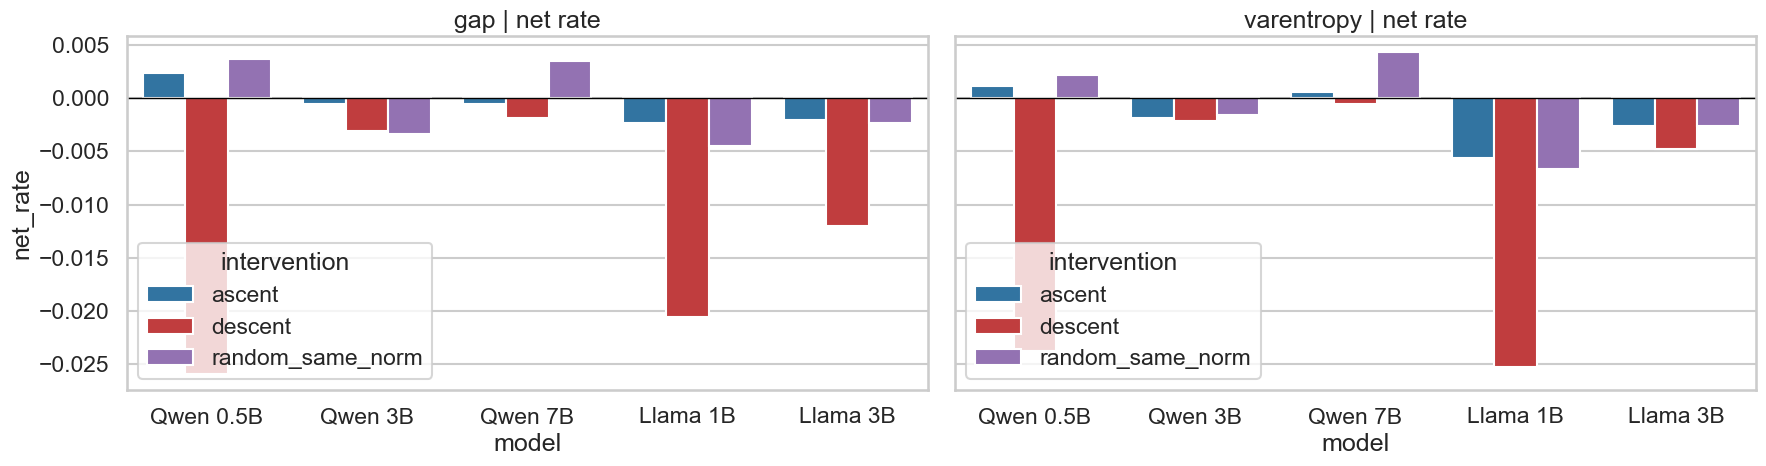

In [14]:
by_feature = all_df.groupby(['model', 'feature', 'intervention_type'], observed=False).agg(
    rows=('example_id', 'size'),
    rescued=('rescued', 'sum'),
    harmed=('harmed', 'sum'),
).reset_index()
by_feature['rescue_rate'] = by_feature['rescued'] / by_feature['rows']
by_feature['harm_rate'] = by_feature['harmed'] / by_feature['rows']
by_feature['net_rate'] = (by_feature['rescued'] - by_feature['harmed']) / by_feature['rows']
by_feature = apply_model_order(by_feature).sort_values(['model', 'feature', 'intervention_type']).reset_index(drop=True)
display(by_feature)

fig, axes = plt.subplots(1, 2, figsize=(18, 5), sharey=True)
for ax, feature in zip(axes, ['gap', 'varentropy']):
    tmp = by_feature[by_feature['feature'] == feature].copy()
    sns.barplot(data=tmp, x='model', y='net_rate', hue='intervention_type', palette=INTERVENTION_COLORS, ax=ax)
    ax.axhline(0, color='black', lw=1)
    ax.set_title(f'{feature} | net rate')
    ax.legend(title='intervention')
plt.tight_layout()
plt.show()


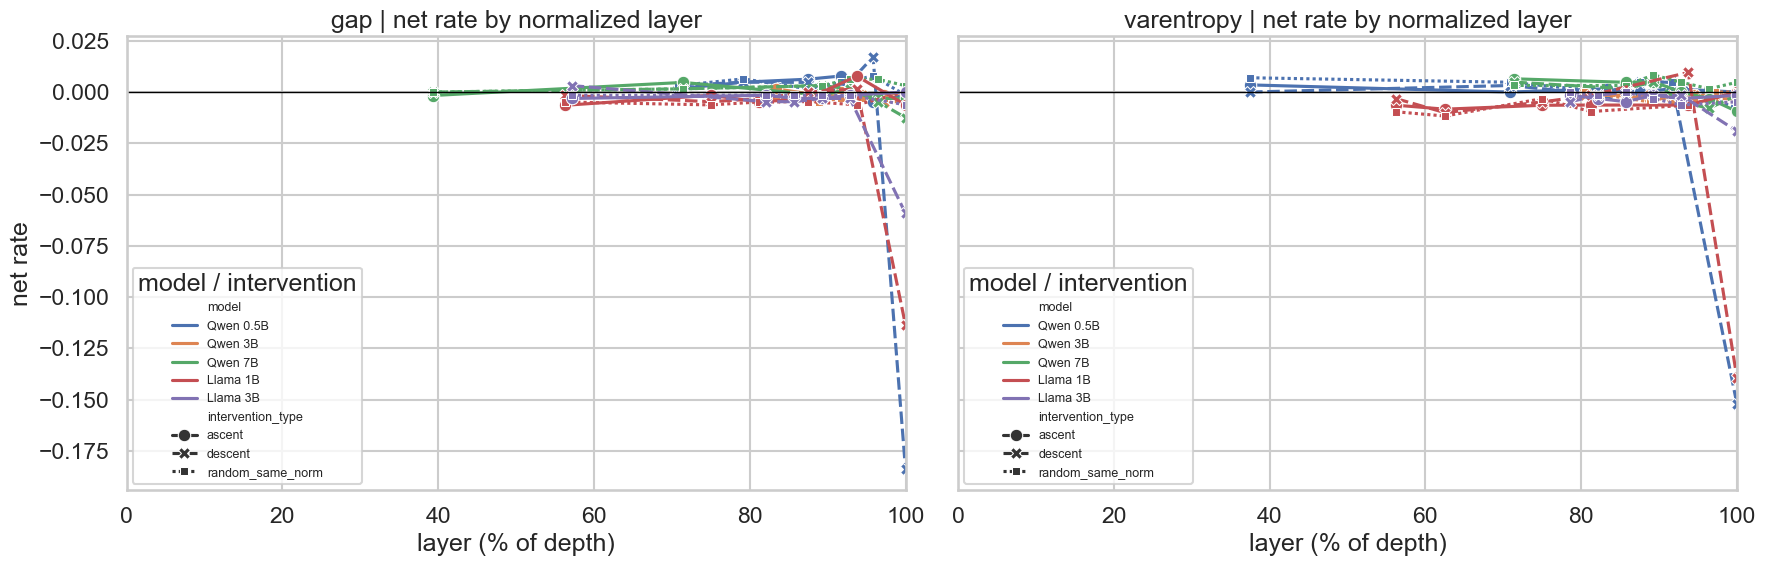

In [15]:
by_layer = all_df.groupby(['model', 'feature', 'layer_number', 'layer_pct', 'intervention_type'], observed=False).agg(
    rows=('example_id', 'size'),
    rescued=('rescued', 'sum'),
    harmed=('harmed', 'sum'),
).reset_index()
by_layer['net_rate'] = (by_layer['rescued'] - by_layer['harmed']) / by_layer['rows']
by_layer = apply_model_order(by_layer).sort_values(['model', 'intervention_type', 'layer_pct']).reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)
for ax, feature in zip(axes, ['gap', 'varentropy']):
    tmp = by_layer[by_layer['feature'] == feature].copy().sort_values(['model', 'intervention_type', 'layer_pct'])
    sns.lineplot(data=tmp, x='layer_pct', y='net_rate', hue='model', style='intervention_type', markers=True, dashes=True, ax=ax)
    ax.axhline(0, color='black', lw=1)
    ax.set_title(f'{feature} | net rate by normalized layer')
    ax.set_xlabel('layer (% of depth)')
    ax.set_ylabel('net rate')
    ax.set_xlim(0, 100)
    ax.legend(title='model / intervention', fontsize=9)
plt.tight_layout()
plt.show()


## Compare `s(x)` And Correct-Answer Logit Change Across Controls

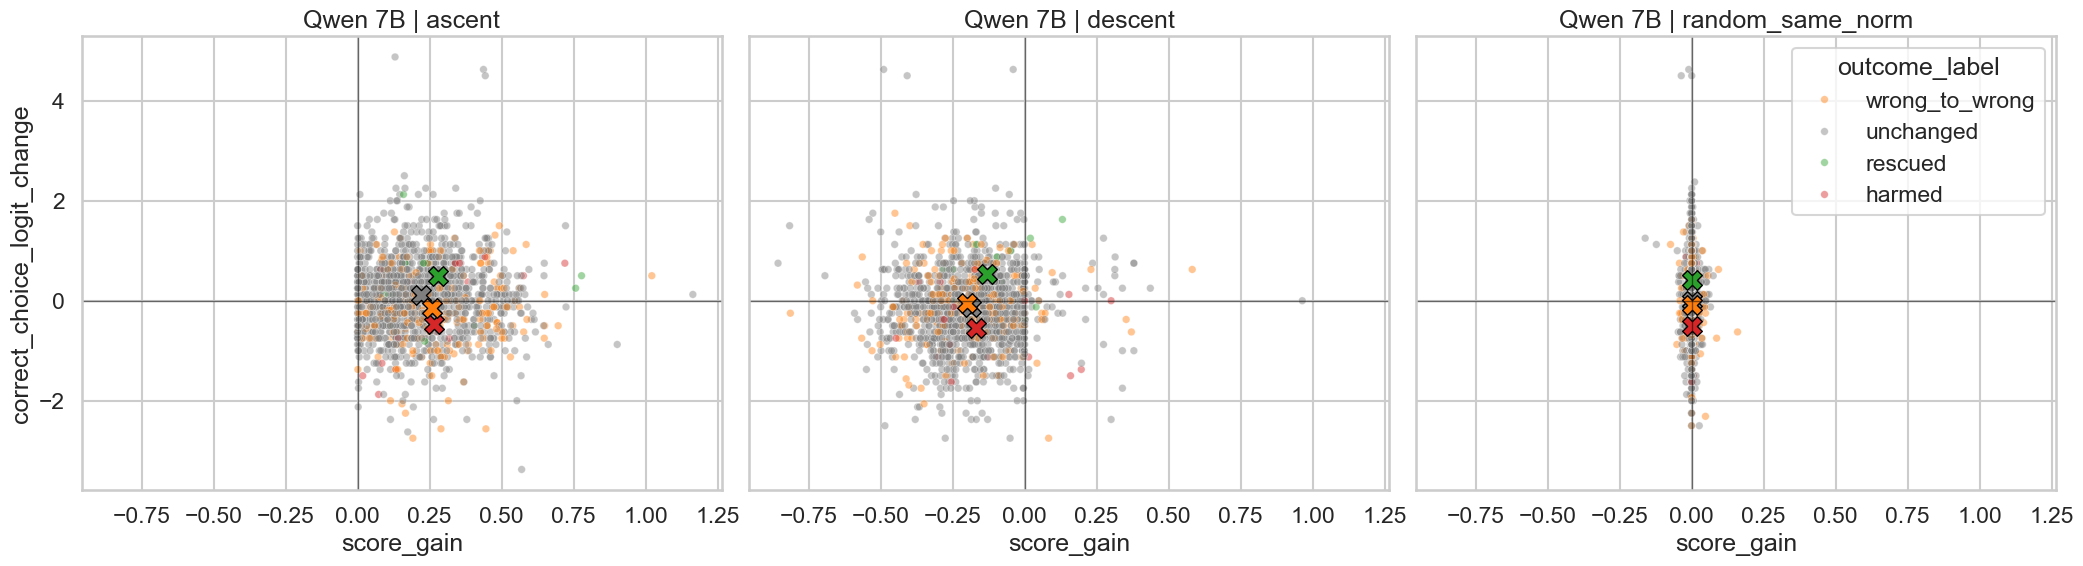

In [28]:
def scatter_score_vs_correct(run, feature_name=None, layer_number=None):
    df = run['df'].copy()
    if feature_name is not None:
        df = df[df['feature_name'] == feature_name].copy()
    if layer_number is not None:
        df = df[df['layer_number'] == layer_number].copy()
    fig, axes = plt.subplots(1, 3, figsize=(21, 6), sharex=True, sharey=True)
    for ax, intervention_type in zip(axes, ['ascent', 'descent', 'random_same_norm']):
        tmp = df[df['intervention_type'] == intervention_type].copy()
        sample = tmp.sample(min(1500, len(tmp)), random_state=42)
        sns.scatterplot(
            data=sample,
            x='score_gain', y='correct_choice_logit_change', hue='outcome_label',
            palette=OUTCOME_COLORS, alpha=0.45, s=30, ax=ax, legend=(intervention_type == 'random_same_norm')
        )
        means = tmp.groupby('outcome_label')[['score_gain', 'correct_choice_logit_change']].mean().reset_index()
        for _, row in means.iterrows():
            ax.scatter(row['score_gain'], row['correct_choice_logit_change'], marker='X', s=200, color=OUTCOME_COLORS[row['outcome_label']], edgecolor='black', linewidth=1)
        ax.set_title(f"{run['label']} | {intervention_type}")
        ax.axvline(0, color='black', lw=1, alpha=0.5)
        ax.axhline(0, color='black', lw=1, alpha=0.5)
        ax.set_xlabel('score_gain')
        ax.set_ylabel('correct_choice_logit_change')
    plt.tight_layout()
    plt.show()

MODEL = 'Qwen 7B'
FEATURE_NAME = None
LAYER_NUMBER = None
run = next(r for r in runs if r['label'] == MODEL)
scatter_score_vs_correct(run, feature_name=FEATURE_NAME, layer_number=LAYER_NUMBER)


## Start Region And Clean Correctness Breakdown

In [17]:
def region_and_clean_breakdown(run):
    df = run['df'].copy()
    by_region = df.groupby(['intervention_type', 'current_region_label']).agg(rows=('example_id', 'size'), rescued=('rescued', 'sum'), harmed=('harmed', 'sum')).reset_index()
    by_region['net_rate'] = (by_region['rescued'] - by_region['harmed']) / by_region['rows']
    by_clean = df.groupby(['intervention_type', 'clean_is_correct']).agg(rows=('example_id', 'size'), rescued=('rescued', 'sum'), harmed=('harmed', 'sum')).reset_index()
    by_clean['net_rate'] = (by_clean['rescued'] - by_clean['harmed']) / by_clean['rows']
    by_clean['clean_state'] = by_clean['clean_is_correct'].map({False: 'clean wrong', True: 'clean correct'})
    return by_region, by_clean

for run in runs:
    print(f"\n=== {run['label']} by start region ===")
    by_region, by_clean = region_and_clean_breakdown(run)
    display(by_region)
    print(f"\n=== {run['label']} by clean correctness ===")
    display(by_clean[['intervention_type', 'clean_state', 'rows', 'rescued', 'harmed', 'net_rate']])



=== Qwen 0.5B by start region ===


,intervention_type,current_region_label,rows,rescued,harmed,net_rate
0,ascent,bad,924,29,26,0.003247
1,ascent,good,1077,0,2,-0.001857
2,ascent,neutral,5510,56,44,0.002178
3,ascent,unsupported,16,1,1,0.000000
4,descent,bad,924,93,93,0.000000
5,descent,good,1077,7,16,-0.008357
6,descent,neutral,5510,197,377,-0.032668
7,descent,unsupported,16,2,0,0.125000
8,random_same_norm,bad,924,23,15,0.008658
9,random_same_norm,good,1077,1,2,-0.000929



=== Qwen 0.5B by clean correctness ===


,intervention_type,clean_state,rows,rescued,harmed,net_rate
0,ascent,clean wrong,3340,86,0,0.025749
1,ascent,clean correct,4187,0,73,-0.017435
2,descent,clean wrong,3340,299,0,0.089521
3,descent,clean correct,4187,0,486,-0.116074
4,random_same_norm,clean wrong,3340,86,0,0.025749
5,random_same_norm,clean correct,4187,0,64,-0.015285



=== Qwen 3B by start region ===


...

,intervention_type,clean_state,rows,rescued,harmed,net_rate
0,ascent,clean wrong,3690,56,0,0.015176
1,ascent,clean correct,3841,0,86,-0.022390
2,descent,clean wrong,3690,286,0,0.077507
3,descent,clean correct,3841,0,458,-0.119240
4,random_same_norm,clean wrong,3690,52,0,0.014092
5,random_same_norm,clean correct,3841,0,94,-0.024473



=== Llama 3B by start region ===


,intervention_type,current_region_label,rows,rescued,harmed,net_rate
0,ascent,bad,2470,16,23,-0.002834
1,ascent,good,2297,1,0,0.000435
2,ascent,neutral,2835,9,21,-0.004233
3,ascent,unsupported,24,2,2,0.000000
4,descent,bad,2470,73,125,-0.021053
5,descent,good,2297,2,0,0.000871
6,descent,neutral,2835,27,43,-0.005644
7,descent,unsupported,24,5,3,0.083333
8,random_same_norm,bad,2470,8,24,-0.006478
9,random_same_norm,good,2297,2,0,0.000871



=== Llama 3B by clean correctness ===


,intervention_type,clean_state,rows,rescued,harmed,net_rate
0,ascent,clean wrong,2525,28,0,0.011089
1,ascent,clean correct,5101,0,46,-0.009018
2,descent,clean wrong,2525,107,0,0.042376
3,descent,clean correct,5101,0,171,-0.033523
4,random_same_norm,clean wrong,2525,26,0,0.010297
5,random_same_norm,clean correct,5101,0,45,-0.008822


## Feature/Layer Tables: Best And Worst Control Outcomes

In [18]:
for run in runs:
    print(f"\n=== {run['label']} best/worst feature-layer-control rows ===")
    tmp = run['df'].groupby(['feature_name', 'layer_number', 'intervention_type']).agg(
        rows=('example_id', 'size'),
        rescued=('rescued', 'sum'),
        harmed=('harmed', 'sum'),
        mean_score_gain=('score_gain', 'mean'),
        mean_correct_logit_change=('correct_choice_logit_change', 'mean'),
    ).reset_index()
    tmp['net_rate'] = (tmp['rescued'] - tmp['harmed']) / tmp['rows']
    display(tmp.sort_values(['net_rate', 'rescued'], ascending=False).head(12))
    display(tmp.sort_values(['net_rate', 'harmed'], ascending=True).head(12))



=== Qwen 0.5B best/worst feature-layer-control rows ===


,feature_name,layer_number,intervention_type,rows,rescued,harmed,mean_score_gain,mean_correct_logit_change,net_rate
13,answer_choice_top1_top2_logit_gap,23,descent,643,20,9,-0.117793,0.009234,0.017107
9,answer_choice_top1_top2_logit_gap,22,ascent,641,10,5,0.149398,0.032371,0.007800
14,answer_choice_top1_top2_logit_gap,23,random_same_norm,643,9,4,0.000448,0.026050,0.007776
20,answer_choice_varentropy,9,random_same_norm,575,9,5,-0.000658,0.026739,0.006957
5,answer_choice_top1_top2_logit_gap,19,random_same_norm,624,9,5,-0.000472,0.020333,0.006410
6,answer_choice_top1_top2_logit_gap,21,ascent,638,8,4,0.174739,0.024001,0.006270
29,answer_choice_varentropy,21,random_same_norm,612,8,5,0.000095,0.018484,0.004902
28,answer_choice_varentropy,21,descent,612,7,4,-0.072697,0.017872,0.004902
4,answer_choice_top1_top2_logit_gap,19,descent,624,9,6,-0.113466,0.017628,0.004808
3,answer_choice_top1_top2_logit_gap,19,ascent,624,7,4,0.129429,0.024439,0.004808


,feature_name,layer_number,intervention_type,rows,rescued,harmed,mean_score_gain,mean_correct_logit_change,net_rate
16,answer_choice_top1_top2_logit_gap,24,descent,641,108,226,-0.185528,-0.370125,-0.184087
34,answer_choice_varentropy,24,descent,625,105,200,-0.099634,0.081300,-0.152000
35,answer_choice_varentropy,24,random_same_norm,625,4,9,-0.000431,0.005300,-0.008000
12,answer_choice_top1_top2_logit_gap,23,ascent,643,10,13,0.141879,0.021870,-0.004666
25,answer_choice_varentropy,20,descent,634,4,5,-0.118278,0.015576,-0.001577
17,answer_choice_top1_top2_logit_gap,24,random_same_norm,641,5,6,0.000029,0.014723,-0.001560
15,answer_choice_top1_top2_logit_gap,24,ascent,641,6,7,0.258131,0.394208,-0.001560
33,answer_choice_varentropy,24,ascent,625,4,4,0.116826,-0.064000,0.000000
19,answer_choice_varentropy,9,descent,575,5,5,-0.106871,0.016413,0.000000
26,answer_choice_varentropy,20,random_same_norm,634,5,5,0.000305,0.018237,0.000000



=== Qwen 3B best/worst feature-layer-control rows ===


,feature_name,layer_number,intervention_type,rows,rescued,harmed,mean_score_gain,mean_correct_logit_change,net_rate
0,answer_choice_top1_top2_logit_gap,30,ascent,639,5,4,0.389654,-0.027387,0.001565
18,answer_choice_varentropy,29,ascent,617,4,4,0.194763,-0.020057,0.000000
32,answer_choice_varentropy,35,random_same_norm,632,4,4,0.000794,-0.026108,0.000000
6,answer_choice_top1_top2_logit_gap,33,ascent,644,3,3,0.169828,-0.018634,0.000000
20,answer_choice_varentropy,29,random_same_norm,617,3,3,-0.000655,-0.011750,0.000000
35,answer_choice_varentropy,36,random_same_norm,609,3,3,0.000259,-0.026478,0.000000
15,answer_choice_top1_top2_logit_gap,36,ascent,640,1,1,0.231187,0.222461,0.000000
10,answer_choice_top1_top2_logit_gap,34,descent,645,5,6,-0.179797,-0.048643,-0.001550
9,answer_choice_top1_top2_logit_gap,34,ascent,645,2,3,0.167571,-0.014147,-0.001550
7,answer_choice_top1_top2_logit_gap,33,descent,644,4,5,-0.172527,-0.029309,-0.001553


...

,feature_name,layer_number,intervention_type,rows,rescued,harmed,mean_score_gain,mean_correct_logit_change,net_rate
31,answer_choice_varentropy,15,descent,628,12,6,-0.078667,0.001194,0.009554
12,answer_choice_top1_top2_logit_gap,15,ascent,643,13,8,0.114027,0.010498,0.007776
13,answer_choice_top1_top2_logit_gap,15,descent,643,10,9,-0.104991,0.003499,0.001555
17,answer_choice_top1_top2_logit_gap,16,random_same_norm,642,7,7,0.000187,0.005062,0.000000
10,answer_choice_top1_top2_logit_gap,14,descent,642,6,6,-0.099225,0.006425,0.000000
35,answer_choice_varentropy,16,random_same_norm,632,6,6,-0.000835,0.001978,0.000000
33,answer_choice_varentropy,16,ascent,632,3,3,0.214715,0.180182,0.000000
3,answer_choice_top1_top2_logit_gap,12,ascent,637,5,6,0.228587,0.011185,-0.001570
28,answer_choice_varentropy,13,descent,630,5,6,-0.042997,0.005556,-0.001587
1,answer_choice_top1_top2_logit_gap,9,descent,617,7,8,-0.079126,0.011750,-0.001621


,feature_name,layer_number,intervention_type,rows,rescued,harmed,mean_score_gain,mean_correct_logit_change,net_rate
34,answer_choice_varentropy,16,descent,632,97,185,-0.190140,-0.176028,-0.139241
16,answer_choice_top1_top2_logit_gap,16,descent,642,126,199,-0.183833,-0.220989,-0.113707
23,answer_choice_varentropy,10,random_same_norm,598,2,9,0.000098,0.006480,-0.011706
22,answer_choice_varentropy,10,descent,598,3,9,-0.040631,0.005644,-0.010033
20,answer_choice_varentropy,9,random_same_norm,623,3,9,0.000244,0.009430,-0.009631
29,answer_choice_varentropy,13,random_same_norm,630,3,9,0.000113,0.004563,-0.009524
21,answer_choice_varentropy,10,ascent,598,4,9,0.183670,0.005435,-0.008361
0,answer_choice_top1_top2_logit_gap,9,ascent,617,3,7,0.092222,-0.001823,-0.006483
24,answer_choice_varentropy,12,ascent,619,3,7,0.166650,0.009491,-0.006462
18,answer_choice_varentropy,9,ascent,623,3,7,0.141578,0.010433,-0.006421



=== Llama 3B best/worst feature-layer-control rows ===


,feature_name,layer_number,intervention_type,rows,rescued,harmed,mean_score_gain,mean_correct_logit_change,net_rate
1,answer_choice_top1_top2_logit_gap,16,descent,637,4,2,-0.192565,0.006672,0.003140
25,answer_choice_varentropy,24,descent,639,4,4,-0.156158,0.005869,0.000000
26,answer_choice_varentropy,24,random_same_norm,639,4,4,-0.000136,0.010563,0.000000
20,answer_choice_varentropy,22,random_same_norm,629,3,3,0.000267,0.007949,0.000000
15,answer_choice_top1_top2_logit_gap,28,ascent,642,2,2,0.336625,0.171924,0.000000
12,answer_choice_top1_top2_logit_gap,26,ascent,641,3,4,0.096893,0.011700,-0.001560
14,answer_choice_top1_top2_logit_gap,26,random_same_norm,641,2,3,-0.000309,0.007605,-0.001560
11,answer_choice_top1_top2_logit_gap,25,random_same_norm,639,3,4,0.000306,0.008216,-0.001565
8,answer_choice_top1_top2_logit_gap,24,random_same_norm,638,2,3,-0.000008,0.007249,-0.001567
5,answer_choice_top1_top2_logit_gap,23,random_same_norm,637,3,4,-0.000121,0.008242,-0.001570


,feature_name,layer_number,intervention_type,rows,rescued,harmed,mean_score_gain,mean_correct_logit_change,net_rate
16,answer_choice_top1_top2_logit_gap,28,descent,642,50,88,-0.260811,-0.152064,-0.059190
34,answer_choice_varentropy,28,descent,630,36,48,-0.231620,0.010020,-0.019048
32,answer_choice_varentropy,26,random_same_norm,631,2,6,0.000049,0.006141,-0.006339
17,answer_choice_top1_top2_logit_gap,28,random_same_norm,642,0,4,-0.000666,0.007593,-0.006231
19,answer_choice_varentropy,22,descent,629,2,5,-0.090084,0.009539,-0.004769
35,answer_choice_varentropy,28,random_same_norm,630,1,4,-0.000784,0.005159,-0.004762
4,answer_choice_top1_top2_logit_gap,23,descent,637,2,5,-0.091875,0.009027,-0.004710
7,answer_choice_top1_top2_logit_gap,24,descent,638,0,3,-0.127120,0.006074,-0.004702
24,answer_choice_varentropy,24,ascent,639,2,5,0.163090,0.008216,-0.004695
29,answer_choice_varentropy,25,random_same_norm,631,1,3,-0.000492,0.006933,-0.003170
